In [9]:
# =====================================================================
# CELL 1: IMPORT THƯ VIỆN & CẤU HÌNH
# Nhiệm vụ: Tải các công cụ cần thiết cho toàn bộ quá trình xử lý.
# =====================================================================

import pandas as pd                  # Xử lý và phân tích dữ liệu dạng bảng (DataFrame)
import numpy as np                   # Tính toán toán học và mảng dữ liệu
import matplotlib.pyplot as plt      # Thư viện vẽ biểu đồ cơ bản
import seaborn as sns                # Thư viện vẽ biểu đồ đẹp và dễ dùng hơn (dựa trên matplotlib)
import re                            # Thư viện xử lý Biểu thức chính quy (Regex) để tìm kiếm chuỗi
from urllib.parse import urlparse    # Công cụ để bóc tách URL (lấy domain, path, scheme...)
from sklearn.model_selection import train_test_split  # Hàm chia tập dữ liệu Train/Test
from sklearn.ensemble import RandomForestClassifier   # Mô hình học máy Random Forest
from sklearn.metrics import classification_report     # Hàm tạo báo cáo đánh giá mô hình (Precision, Recall, F1)

# Cấu hình hiển thị biểu đồ xuất hiện ngay trong Notebook
%matplotlib inline
# Đặt giao diện lưới nền trắng cho biểu đồ Seaborn thêm dễ nhìn
sns.set_theme(style="whitegrid")

In [10]:
# =====================================================================
# CELL 2: TIỀN XỬ LÝ DỮ LIỆU (DATA PREPROCESSING)
# Nhiệm vụ: Đọc file CSV, loại bỏ dữ liệu rác, lỗi hoặc trùng lặp.
# =====================================================================

print("Đang đọc và làm sạch dữ liệu...")

# 1. Đọc file CSV
# Dùng try-except để bắt lỗi nếu quên chưa để file data cùng thư mục với notebook
try:
    # low_memory=False giúp Pandas đọc các file lớn mà không bị cảnh báo ép kiểu dữ liệu
    df = pd.read_csv("phishing_site_urls.csv", names=['url', 'label'], header=None, low_memory=False)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy file 'phishing_site_urls.csv'. Vui lòng kiểm tra lại đường dẫn.")

# 2. Chuẩn hóa văn bản
# Ép kiểu dữ liệu về dạng chuỗi (string) và xóa khoảng trắng ở 2 đầu (.str.strip())
df['url'] = df['url'].astype(str).str.strip()
df['label'] = df['label'].astype(str).str.strip().str.lower() # Chuyển nhãn về chữ thường

# 3. Xử lý giá trị khuyết thiếu (Missing Values)
# Biến các chuỗi rỗng thành giá trị NaN chuẩn của Numpy, sau đó xóa bỏ các dòng chứa NaN
df.replace(["", "nan", "none"], np.nan, inplace=True)
df.dropna(subset=['url', 'label'], inplace=True)

# 4. Lọc nhãn và xóa trùng lặp (Drop Duplicates)
# Chỉ giữ lại các dòng có nhãn là 'good' (an toàn) hoặc 'bad' (độc hại)
df = df[df['label'].isin(['good', 'bad'])]
# Xóa các URL bị trùng lặp, chỉ giữ lại bản ghi xuất hiện đầu tiên
df.drop_duplicates(subset=['url'], keep='first', inplace=True)

# 5. Lưu lại dữ liệu đã làm sạch để dùng cho lần sau (không cần chạy lại bước này)
CLEANED_FILE = "phishing_urls_cleaned.csv"
df.to_csv(CLEANED_FILE, index=False)
print(f"Hoàn tất! Dữ liệu hiện tại có {len(df)} dòng.")

Đang đọc và làm sạch dữ liệu...
Hoàn tất! Dữ liệu hiện tại có 507192 dòng.


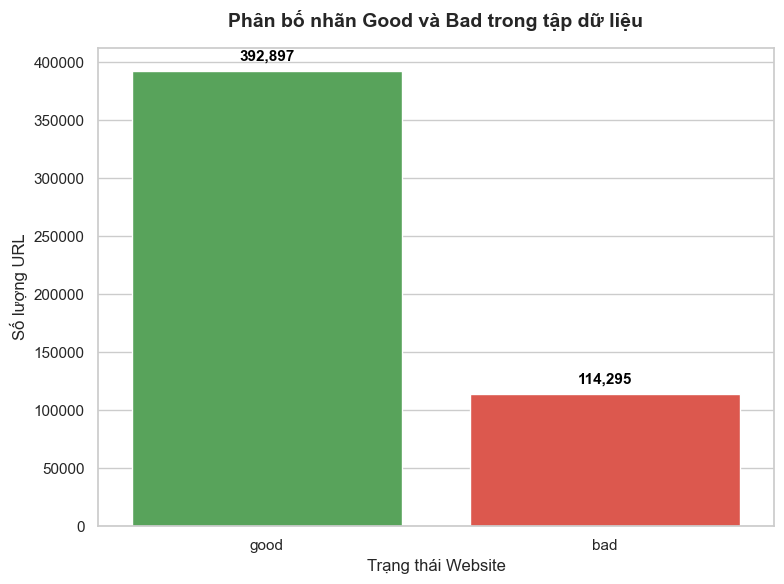

In [11]:
# =====================================================================
# CELL 3: TRỰC QUAN HÓA (EDA - Exploratory Data Analysis)
# Nhiệm vụ: Vẽ biểu đồ xem dữ liệu bị mất cân bằng (imbalanced) ra sao.
# =====================================================================

# Khởi tạo khung biểu đồ kích thước 8x6 inch
plt.figure(figsize=(8, 6))

# Đặt màu sắc: Xanh lá cho Good, Đỏ cho Bad
palette_colors = {"good": "#4CAF50", "bad": "#F44336"}

# Vẽ biểu đồ cột đếm số lượng (countplot)
ax = sns.countplot(
    data=df,
    x='label',
    hue='label',
    order=['good', 'bad'],     # Cố định thứ tự Good đứng trước Bad
    palette=palette_colors,    # Áp dụng màu đã cài đặt
    legend=False               # Ẩn chú thích vì trục X đã ghi rõ Good/Bad
)

# Cấu hình tiêu đề và nhãn các trục
plt.title('Phân bố nhãn Good và Bad trong tập dữ liệu', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Trạng thái Website', fontsize=12)
plt.ylabel('Số lượng URL', fontsize=12)

# Vòng lặp này giúp viết những con số đếm chính xác lên trên đỉnh của mỗi cột
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', # Định dạng số có dấu phẩy (ví dụ: 100,000)
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color='black', xytext=(0, 5),
                textcoords='offset points')

# Tự động căn chỉnh các thành phần để không bị lẹm chữ ra ngoài đồ thị
plt.tight_layout()
plt.show()

In [12]:
# =====================================================================
# CELL 4: FEATURE ENGINEERING (Định nghĩa hàm)
# Nhiệm vụ: Chuyển đổi một chuỗi URL thành các con số đặc trưng để AI học.
# =====================================================================

# TỐI ƯU HÓA: Biên dịch (compile) Regex 1 lần duy nhất ở ngoài hàm
IP_PATTERN = re.compile(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$') # Mẫu kiểm tra định dạng IP (VD: 192.168.1.1)
SHORTENING_SERVICES = re.compile(r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|lnkd\.in|db\.tt|qr\.ae|adf\.ly|cutt\.us|u\.bb|yourls\.org')
SUSPICIOUS_KEYWORDS = ['login', 'update', 'account', 'bank', 'secure', 'paypal', 'confirm', 'free', 'bonus', 'signin', 'admin']

def extract_features(url):
    """
    Hàm này nhận vào 1 URL và trả về 1 dictionary chứa 37 đặc trưng (features) của URL đó.
    """
    features = {}

    # 1. Bóc tách URL an toàn bằng try-except (Tránh lỗi văng chương trình nếu URL bị hỏng)
    try:
        if not isinstance(url, str):
            url = str(url)
        # Bổ sung scheme http:// nếu URL bị thiếu để hàm urlparse hoạt động đúng
        if not url.startswith('http'):
            parsed_url = urlparse('http://' + url)
        else:
            parsed_url = urlparse(url)

        domain = parsed_url.netloc # Lấy phần tên miền (Ví dụ: www.google.com)
        path = parsed_url.path     # Lấy phần đường dẫn phía sau tên miền
    except ValueError:
        domain, path = "", ""

    # 2. Nhóm đặc trưng: Độ dài (Phishing thường dùng URL rất dài để đánh lừa)
    features['url_length'] = len(url)
    features['domain_length'] = len(domain)
    features['path_length'] = len(path)

    # 3. Nhóm đặc trưng: Ký tự đặc biệt (Phishing hay lạm dụng dấu chấm, gạch ngang, @)
    chars_to_count = ['.', '-', '_', '/', '?', '=', '@', '&', '!', ' ', '~', ',', '+', '*', '#', '$', '%']
    for char in chars_to_count:
        # Đặt tên cột mapping để tránh lỗi thư viện Pandas khi tên cột có ký tự lạ
        char_name = char.replace('.', 'dot').replace('-', 'hyphen').replace('_', 'underline').replace('/', 'slash').replace('?', 'questionmark').replace('=', 'equal').replace('@', 'at').replace('&', 'and').replace('!', 'exclamation').replace(' ', 'space').replace('~', 'tilde').replace(',', 'comma').replace('+', 'plus').replace('*', 'asterisk').replace('#', 'hashtag').replace('$', 'dollar').replace('%', 'percent')
        features[f'qty_{char_name}'] = url.count(char)

    # 4. Nhóm đặc trưng: Số học
    qty_digits = sum(c.isdigit() for c in url)  # Đếm số lượng chữ số
    qty_letters = sum(c.isalpha() for c in url) # Đếm số lượng chữ cái
    features['qty_digits'] = qty_digits
    features['qty_letters'] = qty_letters
    features['digit_letter_ratio'] = qty_digits / max(1, qty_letters) # Tỷ lệ số / chữ (Càng cao càng đáng ngờ)

    # 5. Nhóm đặc trưng: Cấu trúc & Dấu hiệu (Kiến thức CEH)
    features['use_of_ip'] = 1 if IP_PATTERN.match(domain) else 0             # Bắt lỗi dùng IP thay vì Domain
    features['shortening_service'] = 1 if SHORTENING_SERVICES.search(domain) else 0 # Bắt lỗi dùng link rút gọn
    features['qty_subdirectories'] = path.count('/')                         # Đếm số lượng thư mục con

    # 6. Nhóm đặc trưng: Từ khóa nhạy cảm
    url_lower = url.lower()
    for kw in SUSPICIOUS_KEYWORDS:
        # Trả về 1 nếu URL chứa từ khóa đáng ngờ, ngược lại trả về 0
        features[f'has_kw_{kw}'] = 1 if kw in url_lower else 0

    return features

In [13]:
# =====================================================================
# CELL 5: CHẠY FEATURE ENGINEERING
# Nhiệm vụ: Áp dụng hàm vừa tạo lên toàn bộ dữ liệu. Mất khoảng vài phút.
# =====================================================================

print("Đang trích xuất đặc trưng cho các URLs. Vui lòng chờ...")

# Hàm apply() sẽ duyệt qua từng dòng của cột 'url' và đẩy vào hàm extract_features
features_list = df['url'].apply(extract_features)

# Chuyển đổi kết quả (đang là dạng list of dictionary) thành một bảng DataFrame
df_features = pd.DataFrame(features_list.tolist())

# Số hóa nhãn dán: Chuyển 'good' thành 0, 'bad' thành 1.
# Dùng .values để ép kiểu Numpy Array, khắc phục triệt để lỗi lệch Index giữa df và df_features
df_features['label'] = df['label'].map({'good': 0, 'bad': 1}).values

# Đề phòng quá trình xử lý URL gặp lỗi tạo ra giá trị rỗng (NaN), ta tiến hành xóa chúng đi
df_features.dropna(inplace=True)

print(f"Hoàn thành trích xuất {df_features.shape[1] - 1} đặc trưng!")
df_features.head() # In thử 5 dòng đầu tiên để kiểm tra

Đang trích xuất đặc trưng cho các URLs. Vui lòng chờ...
Hoàn thành trích xuất 37 đặc trưng!


,url_length,domain_length,path_length,qty_dot,qty_hyphen,qty_underline,qty_slash,qty_questionmark,qty_equal,qty_at,...,has_kw_account,has_kw_bank,has_kw_secure,has_kw_paypal,has_kw_confirm,has_kw_free,has_kw_bonus,has_kw_signin,has_kw_admin,label
0,225,9,125,6,4,4,10,1,4,0,...,0,0,0,0,0,0,0,0,0,1
1,81,15,66,5,2,1,4,0,2,0,...,0,0,0,1,0,0,0,0,0,1
2,177,16,161,7,1,0,11,0,0,0,...,0,0,1,1,0,0,0,0,0,1
3,60,18,42,6,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,116,19,60,1,1,0,10,1,0,0,...,0,0,0,0,0,0,0,0,0,1


In [14]:
# =====================================================================
# CELL 6: MACHINE LEARNING (TRAIN & EVALUATE)
# Nhiệm vụ: Xây dựng mô hình Random Forest, huấn luyện và chấm điểm.
# =====================================================================

# 1. Tách biến đầu vào X (các đặc trưng) và biến mục tiêu y (nhãn 0/1)
X = df_features.drop('label', axis=1) # Bỏ cột label đi để làm X
y = df_features['label']              # Cột label chính là y

# 2. Chia dữ liệu thành tập Huấn luyện (Train) và tập Kiểm thử (Test)
# test_size=0.2: 80% data để học, 20% data để thi
# stratify=y: Quan trọng! Đảm bảo tỷ lệ Bad/Good ở tập Train và Test giống hệt nhau
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Kích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test: {X_test.shape}")

# 3. Khởi tạo mô hình Random Forest (Rừng ngẫu nhiên)
print("Đang huấn luyện mô hình Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,           # Sử dụng 100 cây quyết định (Decision Trees)
    class_weight='balanced',    # Quan trọng! Giúp AI chú ý hơn tới class bị thiểu số (Bad)
    random_state=42,            # Cố định random để lần chạy sau kết quả không thay đổi
    n_jobs=-1                   # Sử dụng tối đa nhân CPU để huấn luyện nhanh hơn
)

# Cho AI tiến hành "học" trên tập Train
rf_model.fit(X_train, y_train)

# 4. Dự đoán (Làm bài thi) trên tập Test
y_pred = rf_model.predict(X_test)

# 5. In bảng báo cáo điểm số (Precision, Recall, F1-Score)
print("\n" + "="*50)
print("ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad (1)']))

Kích thước tập Train: (405753, 37)
Kích thước tập Test: (101439, 37)
Đang huấn luyện mô hình Random Forest...

ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH
              precision    recall  f1-score   support

    Good (0)       0.94      0.94      0.94     78580
     Bad (1)       0.78      0.79      0.78     22859

    accuracy                           0.90    101439
   macro avg       0.86      0.86      0.86    101439
weighted avg       0.90      0.90      0.90    101439



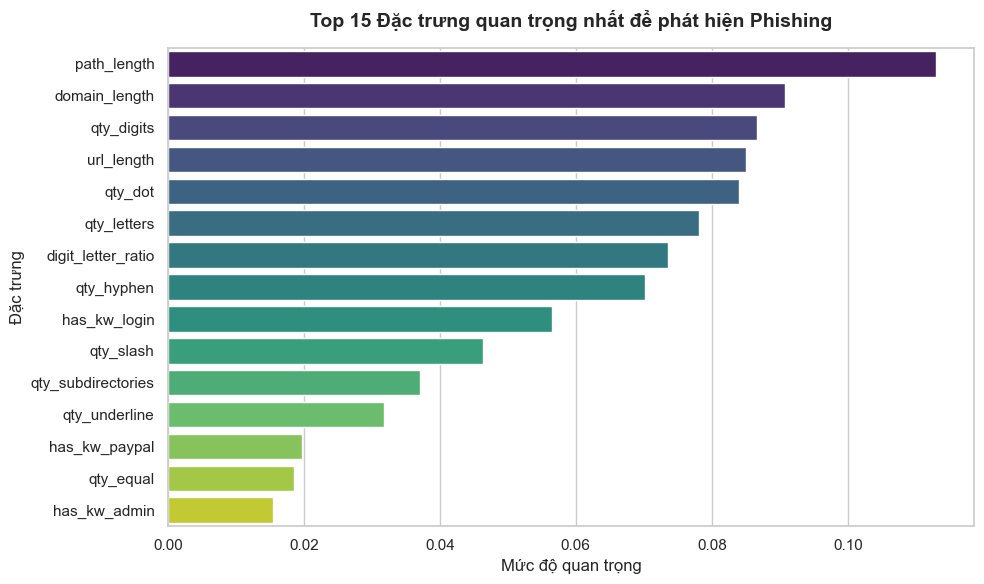

In [15]:
# =====================================================================
# CELL 7: FEATURE IMPORTANCE
# Nhiệm vụ: Khám phá xem AI coi đặc trưng nào là quan trọng nhất để bắt URL độc.
# =====================================================================

# Lấy điểm số độ quan trọng của từng đặc trưng (feature) được AI tự tính toán
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

# Sắp xếp từ cao xuống thấp và chỉ lấy Top 15 đặc trưng mạnh nhất
top_15_features = feature_importances.sort_values(ascending=False).head(15)

# Khởi tạo biểu đồ ngang
plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_15_features.values,
    y=top_15_features.index,
    hue=top_15_features.index, # Áp màu sắc dựa trên tên đặc trưng (trục Y)
    palette="viridis",         # Dải màu Viridis chuẩn khoa học, dễ nhìn
    legend=False               # Tắt chú thích màu sắc
)

# Cấu hình thẩm mỹ
plt.title('Top 15 Đặc trưng quan trọng nhất để phát hiện Phishing', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.ylabel('Đặc trưng', fontsize=12)
plt.tight_layout()

# Hiện biểu đồ
plt.show()